# 미니프로젝트: 앙상블 모델링 (Vibe Coding)

#### <목표>
Day 3에서 배운 **Random Forest, GBM, XGBoost, LightGBM, CatBoost**를 Day 2와 **동일한 제조 데이터셋**에 적용해 봅니다.

- Day 1에서의 EDA, 전처리를 복습해보고
- Day 2에서 배웠던 다중선형회귀·Ridge·Lasso·의사결정나무로 만든 결과와 비교하면서
- Day 3에서 배운 앙상블 모델이 단일 모델 대비 어떤 성능 차이를 보이는지 확인해봅니다.

#### <데이터셋 소개>

**1) 회귀용 — Mining Process Flotation Plant (광물 선광 공정 데이터)**
- 철광석을 선광(flotation)하는 공정에서 1시간 간격으로 수집된 실제 산업 데이터
- 공정 변수로 최종 정광의 불순물(실리카) 비율을 예측

| 변수명 | 설명 |
|:---:|:---|
| date | 측정 일시 |
| % Iron Feed, % Silica Feed | 투입 원광의 철/실리카 품위 |
| Starch Flow, Amina Flow | 전분/아민 투입량 (시약) |
| Ore Pulp Flow, pH, Density | 광액 유량/산도/밀도 |
| Flotation Column 01~07 Air Flow | 플로테이션 컬럼별 공기 유량 |
| Flotation Column 01~07 Level | 플로테이션 컬럼별 액위 |
| % Iron Concentrate | 최종 정광의 철 비율 (실험실 측정) |
| **% Silica Concentrate** | **최종 정광의 실리카(불순물) 비율 — 회귀 타겟** |

**2) 분류용 — Steel Plates Faults (철강 표면 결함 검사 데이터)**
- 철강판 표면을 촬영해 측정한 결함의 위치/크기/광도 등으로 결함 유형을 분류하는 실제 품질검사 데이터

| 변수명 | 설명 |
|:---:|:---|
| X/Y_Minimum, X/Y_Maximum | 결함의 위치 범위 |
| Pixels_Areas, X/Y_Perimeter | 결함의 면적·둘레 |
| Sum/Minimum/Maximum_of_Luminosity | 결함 부위의 광도 |
| Length_of_Conveyer, Steel_Plate_Thickness | 설비/소재 정보 |
| TypeOfSteel_A300, TypeOfSteel_A400 | 철강 타입 |
| Edges_Index, Square_Index, Luminosity_Index 등 | 결함 형태 특징 지수 |
| Pastry, Z_Scratch, K_Scatch, Stains, Dirtiness, Bumps, Other_Faults | 결함 유형 |
| **K_Scatch** | **긴 스크래치성 결함 여부 — 분류 타겟** |

#### <실습 태스크>
| 태스크 | 데이터 파일 | 타겟 변수 | 사용 모델 |
|:---:|:---:|:---:|:---|
| 회귀 | `dataset/day2_miniproject_reg.csv` | `% Silica Concentrate` | Random Forest, GBM, XGBoost, LightGBM, CatBoost (회귀) |
| 분류 | `dataset/day2_miniproject_cls.csv` | `K_Scatch` | Random Forest, GBM, XGBoost, LightGBM, CatBoost (분류) |

#### <진행 순서>
**Part A(회귀)** 를 데이터 불러오기 → 탐색 → 전처리 → 모델링 → 예측 → 고도화 → 결과 해석까지 **끝까지 완료한 뒤**, **Part B(분류)** 를 동일한 흐름으로 진행합니다.

1. 각 섹션의 **과제**를 읽고, 어떤 고민/결정이 필요한지 먼저 생각해 봅니다.
2. 빈 코드 셀을 클릭한 후 Cursor AI 채팅창을 엽니다.
3. 막막한 부분은 AI와 상의해서 방법을 정하고, 그 방법으로 프롬프트를 작성합니다.
4. 생성된 코드를 실행하고 결과를 확인합니다.

## 0) 분석 준비

**[과제]** 써니는 Day 2에서 사용한 회귀 및 분류 데이터셋에 다양한 트리 기반 앙상블 모델을 적용해 보려고 합니다. 분석 준비와 데이터 전처리뿐만 아니라, 앙상블 모델 구축 및 하이퍼파라미터 탐색에 필요한 라이브러리를 AI와 상의하여 선정하고 불러오는 코드를 작성해 보세요.

In [1]:
# =========================
# 0) 공통 — 데이터 로드·EDA·시각화
# =========================
import os
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
plt.rcParams["font.family"] = "Malgun Gothic"   # 한글 폰트 (Windows)
plt.rcParams["axes.unicode_minus"] = False        # 마이너스 기호 깨짐 방지


# =========================
# 1) 데이터 분할·하이퍼파라미터 탐색
# =========================
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold


# =========================
# 2) 전처리 (필요 시)
# =========================
from sklearn.preprocessing import StandardScaler
# 트리 기반 앙상블(RF, GBM, XGBoost, LightGBM, CatBoost)은 스케일링이 필수는 아님
# Day 2 선형 모델과 비교하거나 파이프라인을 쓸 때만 활용


# =========================
# 3) 트리 기반 앙상블 모델
# =========================
# Random Forest
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

# GBM (sklearn)
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor

# XGBoost / LightGBM / CatBoost
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from catboost import CatBoostClassifier, CatBoostRegressor


# =========================
# 4) 평가 지표
# =========================
# 회귀
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# 분류
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
)

In [4]:
# 회귀 데이터셋 불러오기
mining_data = pd.read_csv(os.path.join(os.getcwd(), "dataset", "day2_miniproject_reg.csv"))


---
# Part A. 회귀 태스크 — Mining Process Flotation Plant

## A-0) 데이터 불러오기

**[과제]** 써니는 Day 2에서 사용했던 `dataset/day2_miniproject_reg.csv` 파일을 그대로 불러오려고 합니다. 적절한 변수명으로 데이터프레임을 만들어 보세요.

In [3]:
mining_data

,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
0,3/29/2017 12:00,60.18,9.34,1060.859297,379.836203,400.982539,9.527187,1.550374,200.035839,195.577700,...,249.992956,753.724247,726.559437,860.557818,477.349197,452.512522,478.219647,470.105547,66.44,1.36
1,3/29/2017 13:00,60.18,9.34,2034.926525,322.233975,400.468947,9.700679,1.532017,199.990122,195.106250,...,250.059711,848.675503,777.784437,869.419421,483.816131,469.448172,471.607075,462.665478,66.57,1.43
2,3/29/2017 14:00,60.18,9.34,1435.425811,474.656322,399.157083,9.687788,1.645200,200.019311,195.604928,...,250.111328,851.951492,776.293654,879.704989,456.147231,453.227000,447.708467,453.475667,66.64,1.33
3,3/29/2017 15:00,60.18,9.34,618.460387,396.377733,398.942522,9.851689,1.559929,199.940833,195.657094,...,250.028506,855.910630,780.369869,882.093896,449.410744,448.581506,450.697578,448.660094,66.41,1.27
4,3/29/2017 16:00,59.54,9.56,1367.502858,317.134072,400.836283,9.936163,1.530984,199.878922,196.162864,...,250.122067,851.603513,784.446084,884.840698,450.123050,451.774694,451.574422,449.406894,63.63,5.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3943,9/9/2017 19:00,49.75,23.20,3327.047776,497.211189,380.847200,9.176166,1.660871,301.565561,300.169133,...,298.736661,397.781583,498.753311,403.858956,398.930467,502.971728,399.468911,400.559511,65.05,1.65
3944,9/9/2017 20:00,49.75,23.20,4225.800333,508.963856,381.112889,9.387541,1.691996,300.050172,299.967839,...,303.599269,399.928567,499.648950,399.208611,399.967122,501.624533,398.905006,400.486233,64.83,1.71
3945,9/9/2017 21:00,49.75,23.20,2808.214692,517.748822,381.064411,9.771277,1.735647,299.814289,299.801561,...,309.875439,399.961433,500.484917,471.827489,399.931033,500.223311,401.899806,400.556333,64.29,1.80
3946,9/9/2017 22:00,49.75,23.20,3191.497672,492.511228,380.445006,9.782121,1.716644,300.122756,299.679472,...,305.254558,399.601383,498.614494,836.277192,400.455389,500.406239,402.703283,401.769072,64.25,1.96


---
## A-1) 데이터 탐색 (EDA)

### A-1-1) Value 기반 탐색

**[과제]** 써니는 오늘도 모델링에 앞서 데이터 상태를 다시 한번 점검하고 싶습니다. AI와 함께 데이터 구조, 결측치, 수집 기간 등 기본적인 특성을 다시 확인해 보세요.

In [5]:
mining_data.info()
mining_data.isnull().sum().sort_values(ascending=False).head(10)
mining_data.describe()

<class 'pandas.DataFrame'>
RangeIndex: 3948 entries, 0 to 3947
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   date                          3948 non-null   str    
 1   % Iron Feed                   3948 non-null   float64
 2   % Silica Feed                 3948 non-null   float64
 3   Starch Flow                   3948 non-null   float64
 4   Amina Flow                    3948 non-null   float64
 5   Ore Pulp Flow                 3948 non-null   float64
 6   Ore Pulp pH                   3948 non-null   float64
 7   Ore Pulp Density              3948 non-null   float64
 8   Flotation Column 01 Air Flow  3948 non-null   float64
 9   Flotation Column 02 Air Flow  3948 non-null   float64
 10  Flotation Column 03 Air Flow  3948 non-null   float64
 11  Flotation Column 04 Air Flow  3948 non-null   float64
 12  Flotation Column 05 Air Flow  3948 non-null   float64
 13  Flotation Colu

,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
count,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000,...,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000
mean,56.220301,14.767789,2847.012956,488.720690,397.471417,9.769643,1.679042,281.287417,278.182019,282.253076,...,292.293595,520.425277,523.195899,532.182319,418.095661,422.776652,426.996977,418.128753,65.027176,2.322261
std,5.231150,6.887711,948.913479,83.769854,8.491449,0.378012,0.063417,29.361843,29.490104,28.244196,...,26.527575,123.756672,116.664614,140.549112,76.142141,74.612107,74.714161,71.636366,1.109367,1.120117
min,42.740000,1.310000,54.595483,242.927477,376.837604,8.753389,1.519926,175.885579,178.188430,177.202665,...,199.728122,181.925623,224.909663,135.214506,165.725058,214.735894,203.702926,185.061388,62.050000,0.600000
25%,52.610000,8.812500,2146.232398,436.428747,398.774394,9.542790,1.649868,250.109688,250.119040,250.109164,...,299.031694,409.067986,449.187215,402.250428,351.264361,350.829644,353.171861,350.734692,64.350000,1.440000
50%,55.940000,14.200000,2880.359057,502.685958,399.835435,9.796511,1.694900,299.850578,299.596767,299.893233,...,299.876333,499.582128,499.840739,499.584794,400.834364,400.626158,402.707483,400.495361,65.190000,2.000000
75%,59.720000,20.140000,3514.789671,550.144572,400.592916,10.033416,1.719869,299.955660,299.991808,299.948658,...,300.129489,599.849921,599.424594,600.303602,494.603949,497.296990,489.623260,454.574938,65.830000,2.992500
max,65.780000,33.400000,6270.158798,736.982378,418.070232,10.807370,1.818191,312.295415,309.887767,302.783000,...,351.268656,859.025062,827.775874,884.840698,675.631942,674.068176,698.505832,655.501603,68.010000,5.530000


### A-1-2) Graph 기반 탐색

**[과제]** 써니는 오늘도 어제처럼 시계열 변화 패턴과 변수 간 상관관계를 앙상블 모델링 전에 다시 시각화로 점검하려고 합니다. AI와 함께 시간 흐름에 따른 변수 변화를 시각화해 보세요.

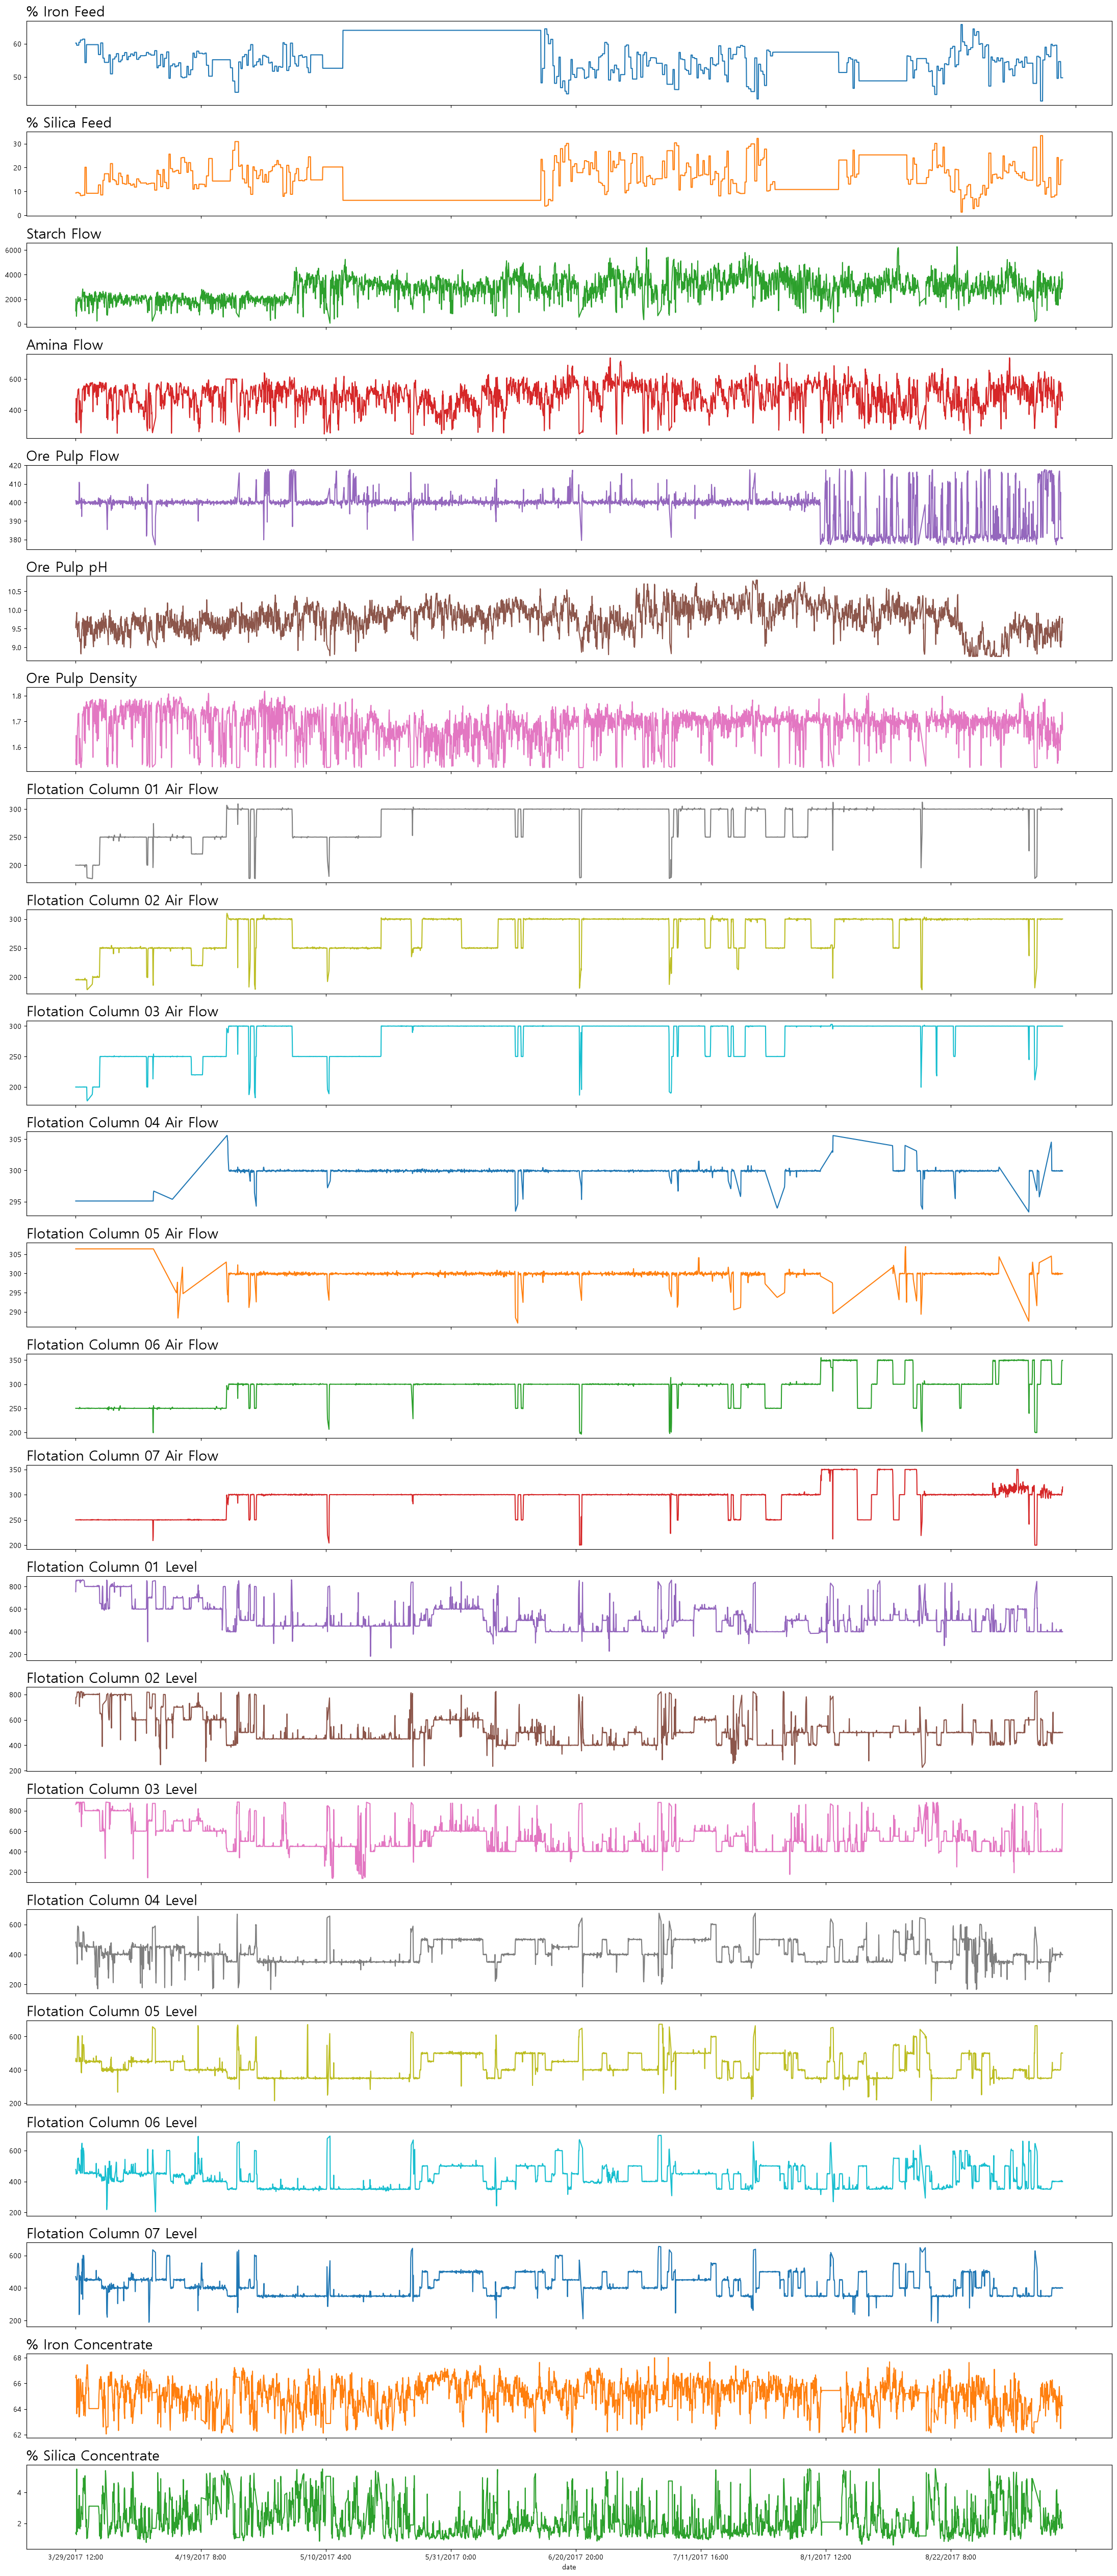

In [6]:
plot_df = mining_data.set_index("date")

axes = plot_df.plot(
    subplots=True,
    figsize=(22, 2.2 * len(plot_df.columns)),
    sharex=True,
    legend=False,
)

for ax, col in zip(axes, plot_df.columns):
    ax.set_title(col, fontsize=20, loc="left")

plt.tight_layout()
plt.show()

**[과제]** 써니는 변수들 간에 강하게 얽혀 있는 관계(다중공선성 후보)가 있는지 한눈에 살펴보고 싶습니다. AI와 상의해서 상관관계 히트맵을 그려보고 트리 기반 앙상블 모델에서는 이 다중공선성이 Day 2의 선형 모델만큼 문제가 되는지도 함께 생각해 보세요.

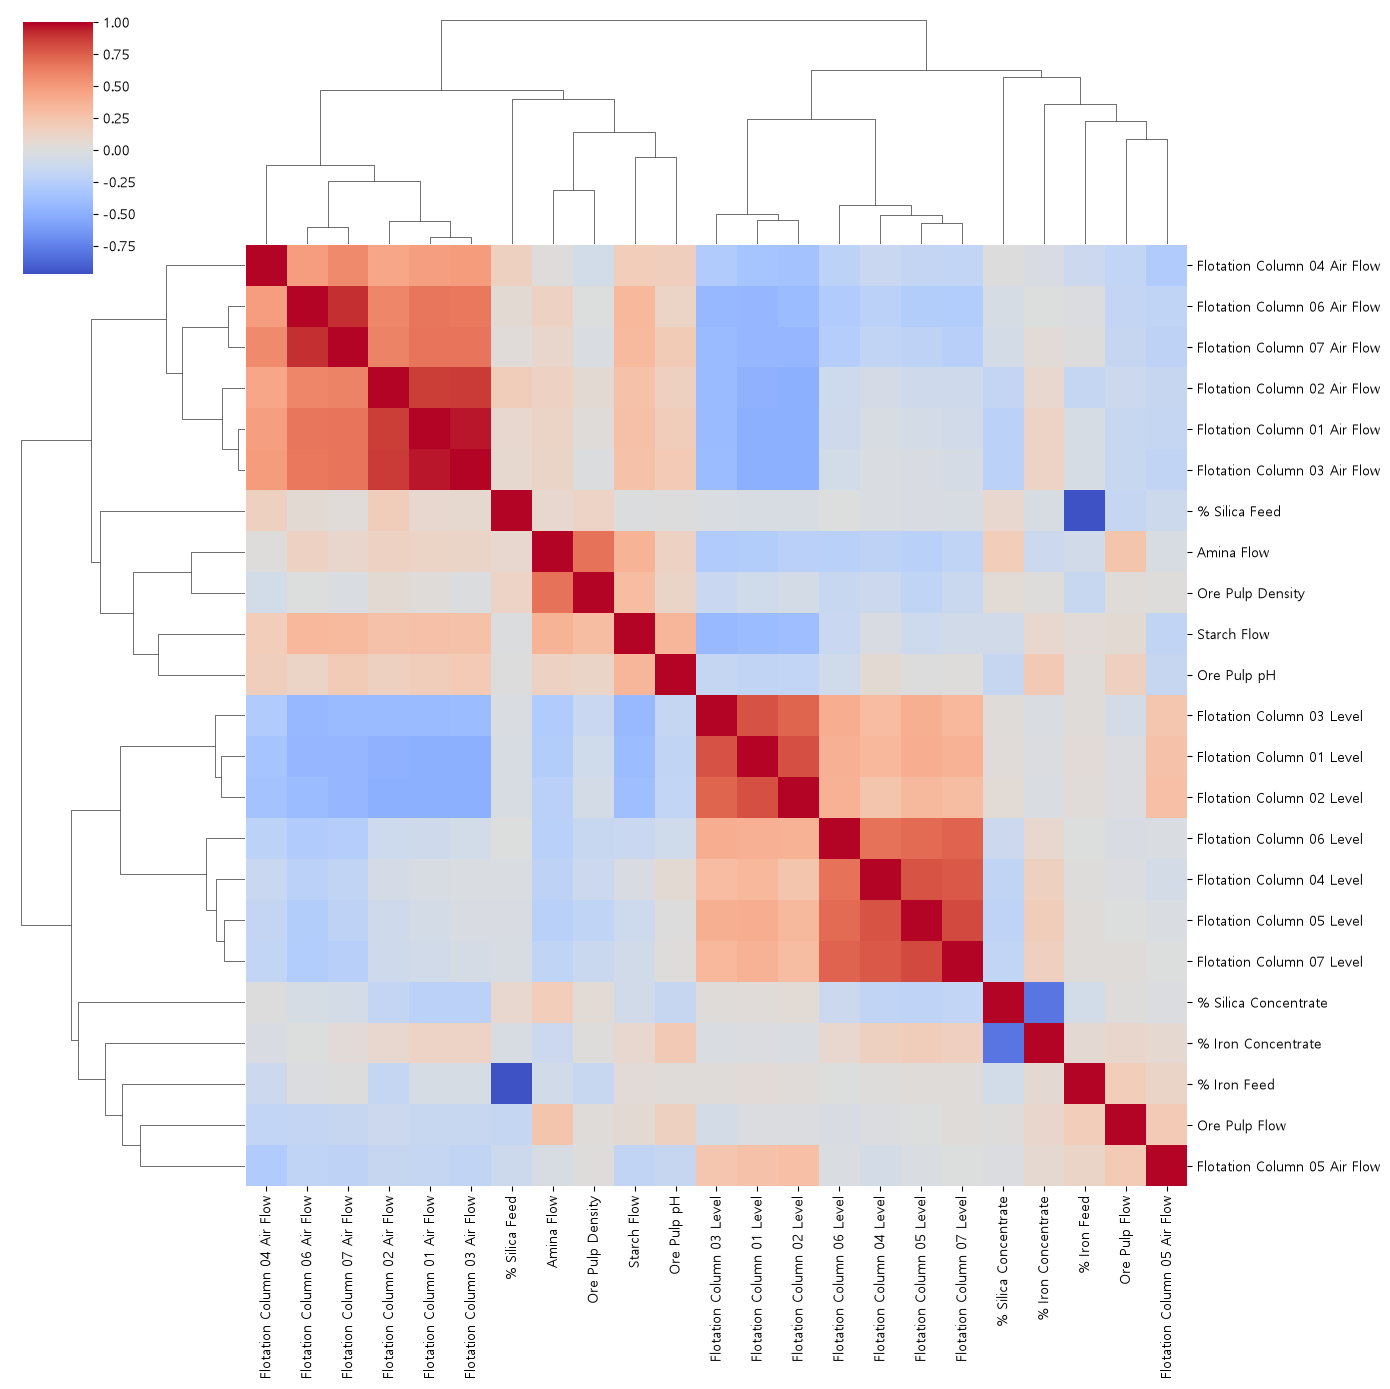

In [7]:
#수치데이터 상관행렬
num_cols = mining_data.select_dtypes(include="number").columns.tolist()
corr = mining_data[num_cols].corr()

#클러스터맵
sns.clustermap(corr, cmap="coolwarm", center=0, figsize=(14, 14))
plt.show()

In [8]:
# |r| >= 0.9 인 강한 상관 쌍 확인
mask = np.triu(np.ones(corr.shape), k=1).astype(bool)
strong_pairs = (
    corr.where(mask)
    .stack()
    .loc[lambda s: s.abs() >= 0.9]
    .sort_values(key=np.abs, ascending=False)
)
print("[Strong correlation pairs] |r| >= 0.9")
display(strong_pairs.to_frame("correlation"))

[Strong correlation pairs] |r| >= 0.9


,,correlation
% Iron Feed,% Silica Feed,-0.972047
Flotation Column 01 Air Flow,Flotation Column 03 Air Flow,0.958320
Flotation Column 06 Air Flow,Flotation Column 07 Air Flow,0.902963


[트리 기반 앙상블 모델에서는 이 다중공선성이 Day 2의 선형 모델만큼 문제가 되는지 궁금합니다.]

트리 모델은 한 번에 하나의 변수로 분할하므로, 선형 모델처럼 “계수가 불안정해지는” 문제는 거의 없습니다.
그래서 예측 성능만 보면 다중공선성 때문에 변수를 꼭 빼지 않아도 되는 경우가 많습니다.
다만 % Iron Concentrate처럼 타겟과 거의 같은 정보는 누수(leakage) 이슈라서, 성능과 별개로 제거 검토가 필요합니다.

---
## A-2) 데이터 전처리

### A-2-1) 불필요한 변수 제거 및 결측치 확인

**[과제]** 써니는 Heatmap을 통해 타겟변수와 강한 상관관계를 가지는 변수를 발견하였습니다. 해당 변수가 데이터 누수를 유발할 수 있는지가 궁금해졌습니다. AI와 함께 상의하여 해당 변수 제거 여부를 검토하고 결정해보세요.

Correlation(% Silica Concentrate, % Iron Concentrate) = -0.8027
→ 최종 정광의 철/실리카 품위는 같은 시점 실험실 측정값이라 입력으로 쓰면 타겟을 사실상 알려주는 데이터 누수가 됩니다.


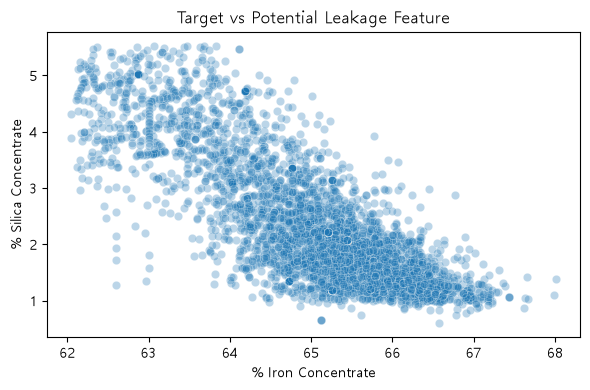

Drop columns: ['date', '% Iron Concentrate']
No missing values.
<class 'pandas.DataFrame'>
RangeIndex: 3948 entries, 0 to 3947
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   % Iron Feed                   3948 non-null   float64
 1   % Silica Feed                 3948 non-null   float64
 2   Starch Flow                   3948 non-null   float64
 3   Amina Flow                    3948 non-null   float64
 4   Ore Pulp Flow                 3948 non-null   float64
 5   Ore Pulp pH                   3948 non-null   float64
 6   Ore Pulp Density              3948 non-null   float64
 7   Flotation Column 01 Air Flow  3948 non-null   float64
 8   Flotation Column 02 Air Flow  3948 non-null   float64
 9   Flotation Column 03 Air Flow  3948 non-null   float64
 10  Flotation Column 04 Air Flow  3948 non-null   float64
 11  Flotation Column 05 Air Flow  3948 non-null   float64
 12  Flotation

In [9]:
# A-2-1) 불필요한 변수 제거 및 결측치 확인

TARGET = "% Silica Concentrate"
LEAK_COL = "% Iron Concentrate"

# 1) 타겟과 % Iron Concentrate 상관 — 데이터 누수 여부 검토
leak_corr = mining_data[[TARGET, LEAK_COL]].corr().iloc[0, 1]
print(f"Correlation({TARGET}, {LEAK_COL}) = {leak_corr:.4f}")
print(
    "→ 최종 정광의 철/실리카 품위는 같은 시점 실험실 측정값이라",
    "입력으로 쓰면 타겟을 사실상 알려주는 데이터 누수가 됩니다."
)

fig, ax = plt.subplots(figsize=(6, 4))
sns.scatterplot(data=mining_data, x=LEAK_COL, y=TARGET, alpha=0.3, ax=ax)
ax.set_xlabel(LEAK_COL)
ax.set_ylabel(TARGET)
ax.set_title("Target vs Potential Leakage Feature")
plt.tight_layout()
plt.show()

# 2) 제거 대상: date(모델 입력 부적합), % Iron Concentrate(누수)
cols_to_drop = ["date", LEAK_COL]
print("Drop columns:", cols_to_drop)
mining_data = mining_data.drop(columns=cols_to_drop)

# 3) 결측치 확인
missing = mining_data.isnull().sum().sort_values(ascending=False)
if missing.any():
    display(missing[missing > 0])
else:
    print("No missing values.")

mining_data.info()

### A-2-2) 입출력 변수 분할 및 데이터 분할

**[과제]** 써니는 `% Silica Concentrate`를 예측하기 위해 입력변수와 타겟 변수를 분리하려고 합니다. Day 2와 마찬가지로 시계열 데이터라는 점을 고려하여 데이터를 분할해보세요.

[프롬프트]
`% Silica Concentrate`를 예측하기 위해 입력변수와 타겟 변수를 분리하려고 합니다. Day 2와 마찬가지로 시계열 데이터라는 점을 고려하여 데이터를 분할해주세요. 특히 측정데이터에 '센서/로깅 문제가 생겨 값이 업데이트되지 않고 ‘마지막 값 유지(hold)’'를 한 구간이 있습니다. 이 구간은 Y값이 없는 것으로 처리해야 할 것 같습니다.

In [10]:
# A-2-2) 입출력 변수 분할 및 시계열 train/test 분할

TARGET = "% Silica Concentrate"

# A-2-1에서 date가 제거되었으므로 원본에서 일시 복원 후 시간순 정렬
_raw = pd.read_csv(os.path.join(os.getcwd(), "dataset", "day2_miniproject_reg.csv"))
_df = mining_data.copy()
_df["date"] = pd.to_datetime(_raw["date"])
_df = _df.sort_values("date").reset_index(drop=True)

# Day 2 EDA: 센서/로깅 hold 구간 — 입력(Feed 등)이 고정·비정상인 기간
HOLD_START = pd.Timestamp("2017-05-13 01:00:00")
HOLD_END = pd.Timestamp("2017-06-15 00:00:00")
hold_mask = (_df["date"] >= HOLD_START) & (_df["date"] <= HOLD_END)

# hold 구간은 Y(타겟)를 결측으로 처리 → 학습·평가에서 제외
Y = _df[TARGET].copy()
Y.loc[hold_mask] = np.nan

X = _df.drop(columns=["date", TARGET])

valid = Y.notna()
X = X.loc[valid].reset_index(drop=True)
Y = Y.loc[valid].reset_index(drop=True)
split_dates = _df.loc[valid, "date"].reset_index(drop=True)

print(f"Sensor hold period: {HOLD_START} ~ {HOLD_END}")
print(f"Rows excluded (Y set to NaN): {hold_mask.sum()}")
print(f"Usable rows: {len(Y)}")
print(f"Time-sorted: {split_dates.is_monotonic_increasing}")

# 시계열 데이터 → shuffle=False (앞 70% 학습, 뒤 30% 테스트)
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.3, shuffle=False
)

split_idx = len(X_train)
print("\nTrain period:", split_dates.iloc[0], "~", split_dates.iloc[split_idx - 1])
print("Test period :", split_dates.iloc[split_idx], "~", split_dates.iloc[-1])
print("\nTrain shape:", X_train.shape, Y_train.shape)
print("Test shape :", X_test.shape, Y_test.shape)

Sensor hold period: 2017-05-13 01:00:00 ~ 2017-06-15 00:00:00
Rows excluded (Y set to NaN): 792
Usable rows: 3156
Time-sorted: True

Train period: 2017-03-29 12:00:00 ~ 2017-08-01 12:00:00
Test period : 2017-08-01 13:00:00 ~ 2017-09-09 23:00:00

Train shape: (2209, 21) (2209,)
Test shape : (947, 21) (947,)


### A-2-3) 스케일링 필요 여부 검토

**[과제]** 써니는 Day 2에서는 Ridge/Lasso 모델 특성 때문에 StandardScaler를 적용했었는데 Day 3에서 사용할 Random Forest·GBM·XGBoost·LightGBM·CatBoost도 스케일링이 꼭 필요한지 AI와 상의해서 판단해 보세요.

In [11]:
# A-2-3) 스케일링 필요 여부 검토

# 변수별 값 범위·분산 확인 (스케일 차이가 큰지 점검)
scale_summary = X_train.describe().loc[["min", "max", "std"]].T
scale_summary["range"] = scale_summary["max"] - scale_summary["min"]
display(scale_summary.sort_values("range", ascending=False).head(10))

print(
    "Day 2 (Ridge/Lasso): 스케일이 다른 변수에 동일한 L2/L1 페널티 → StandardScaler 필요\n"
    "Day 3 (트리 앙상블): 분할이 '값 > 임계값' 기준 → 스케일링해도 분할 순서 동일 (불변)\n"
    "→ RF, GBM, XGBoost, LightGBM, CatBoost는 스케일링 없이 학습"
)

# 이번 회귀 실습: 스케일링 생략
USE_SCALING = False

if USE_SCALING:
    scaler = StandardScaler()
    X_train_fit = pd.DataFrame(
        scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index
    )
    X_test_fit = pd.DataFrame(
        scaler.transform(X_test), columns=X_test.columns, index=X_test.index
    )
else:
    X_train_fit = X_train
    X_test_fit = X_test

print(f"\nUSE_SCALING = {USE_SCALING}")
print("A-3 모델 학습 입력: X_train_fit, X_test_fit")

,min,max,std,range
Starch Flow,54.595483,6187.232444,1038.298552,6132.636961
Flotation Column 03 Level,135.685481,884.840698,150.551934,749.155217
Flotation Column 01 Level,227.017672,859.025062,140.122659,632.007390
Flotation Column 02 Level,246.237621,824.350280,137.603445,578.112658
Flotation Column 04 Level,165.725058,675.631942,73.292227,509.906884
Flotation Column 06 Level,203.702926,698.505832,71.600308,494.802906
Amina Flow,242.927477,736.503275,83.630590,493.575798
Flotation Column 07 Level,188.943287,655.501603,68.550648,466.558316
Flotation Column 05 Level,214.735894,674.068176,70.175416,459.332282
Flotation Column 06 Air Flow,196.512082,354.979117,25.517244,158.467034


Day 2 (Ridge/Lasso): 스케일이 다른 변수에 동일한 L2/L1 페널티 → StandardScaler 필요
Day 3 (트리 앙상블): 분할이 '값 > 임계값' 기준 → 스케일링해도 분할 순서 동일 (불변)
→ RF, GBM, XGBoost, LightGBM, CatBoost는 스케일링 없이 학습

USE_SCALING = False
A-3 모델 학습 입력: X_train_fit, X_test_fit


---
## A-3) 모델 학습 및 예측

**[과제]** 써니는 Day 2에서 학습한 회귀 모델과 Day 3에서 학습한 앙상블 모델을 동일한 데이터셋에 적용하여 성능을 비교해 보고자 합니다. AI와 함께 모델 학습, 예측, 성능 평가 코드를 작성하고, 여러 모델의 결과를 한눈에 비교할 수 있는 방법을 찾아 성능을 비교 및 분석해 보세요.

,RMSE,MAE,R-squared,Train time (s)
Model,,,,
CatBoost,1.078,0.857,0.110,2.996
GBM,1.092,0.876,0.085,1.060
XGBoost,1.168,0.936,-0.047,0.274
LightGBM,1.212,1.007,-0.126,0.079
Random Forest,1.296,1.112,-0.288,0.737


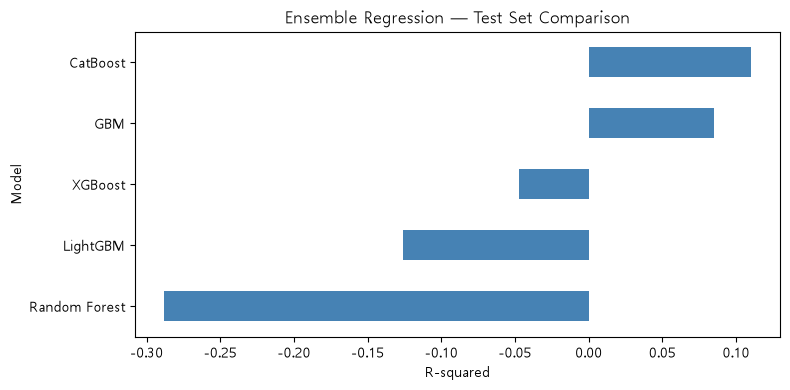

Best model (R-squared): CatBoost


In [12]:
# A-3) 5종 앙상블 회귀 모델 학습 · 예측 · 성능 비교

def eval_regression(y_true, y_pred):
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R-squared": r2_score(y_true, y_pred),
    }

reg_models = {
    "Random Forest": RandomForestRegressor(random_state=0, n_jobs=-1),
    "GBM": GradientBoostingRegressor(random_state=0),
    "XGBoost": XGBRegressor(random_state=0, n_jobs=-1),
    "LightGBM": LGBMRegressor(random_state=0, verbose=-1, n_jobs=-1),
    "CatBoost": CatBoostRegressor(random_state=0, verbose=0),
}

results = []
fitted_models = {}
preds_test = {}

for name, model in reg_models.items():
    t0 = time.time()
    model.fit(X_train_fit, Y_train)
    train_time = time.time() - t0

    pred = model.predict(X_test_fit)
    row = eval_regression(Y_test, pred)
    row["Model"] = name
    row["Train time (s)"] = round(train_time, 3)
    results.append(row)

    fitted_models[name] = model
    preds_test[name] = pred

reg_results = (
    pd.DataFrame(results)
    .set_index("Model")
    .sort_values("R-squared", ascending=False)
    .round(3)
)
display(reg_results)

ax = reg_results["R-squared"].sort_values().plot(
    kind="barh", figsize=(8, 4), color="steelblue"
)
ax.set_xlabel("R-squared")
ax.set_title("Ensemble Regression — Test Set Comparison")
plt.tight_layout()
plt.show()

best_reg_model_name = reg_results["R-squared"].idxmax()
print(f"Best model (R-squared): {best_reg_model_name}")

---
## A-4) 모델 결과 분석 및 고도화

**[과제]** 써니는 Day 2에서 학습한 회귀 모델들과 Day 3에서 학습한 앙상블 모델들이 중요하다고 판단하는 공정 변수가 모델에 따라 얼마나 일관되게 나타나는지 궁금해졌습니다. AI와 함께 변수 중요도 및 회귀 계수를 비교할 수 있는 코드를 작성하고 여러 모델에서 공통적으로 중요하게 선정되는 핵심 공정 변수가 무엇인지 분석해 보세요.

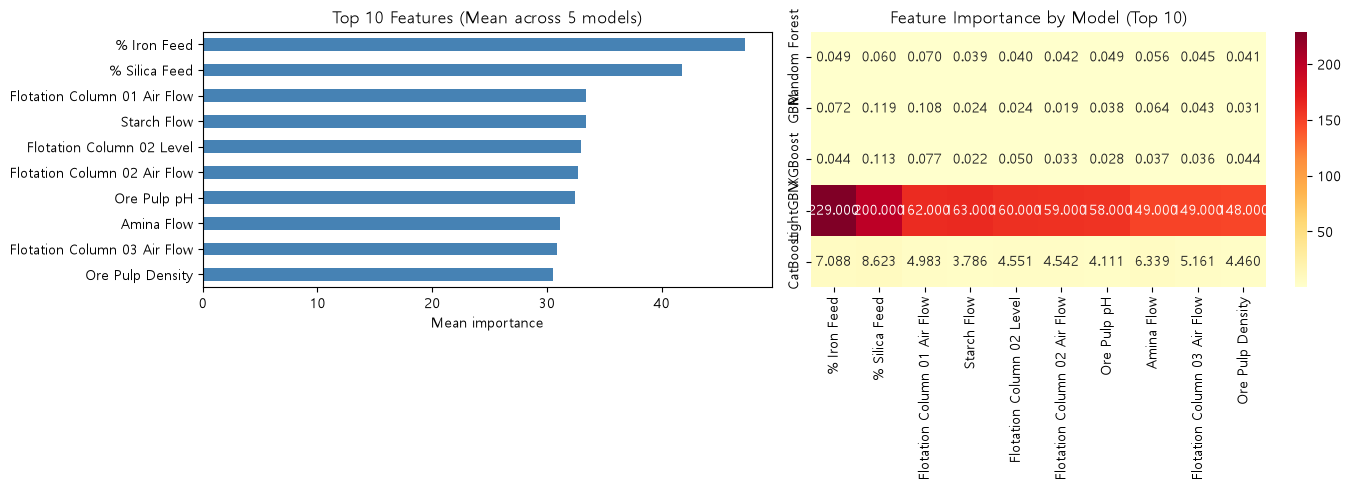

Top-5 inclusion count across models:


% Silica Feed                   5
Flotation Column 04 Air Flow    4
Flotation Column 01 Air Flow    4
% Iron Feed                     3
Amina Flow                      2
Flotation Column 05 Level       2
Flotation Column 06 Level       2
Flotation Column 07 Level       1
Starch Flow                     1
Flotation Column 02 Level       1
dtype: int64


Core process variables (in top-5 for >= 3 models):
['% Silica Feed', 'Flotation Column 04 Air Flow', 'Flotation Column 01 Air Flow', '% Iron Feed']


In [13]:
# A-4-1) 변수 중요도 비교

def get_feature_importance(model, feature_names):
    if hasattr(model, "feature_importances_"):
        imp = model.feature_importances_
    elif hasattr(model, "get_feature_importance"):
        imp = model.get_feature_importance()
    else:
        raise ValueError(type(model))
    return pd.Series(imp, index=feature_names, name="importance")

importance_df = pd.DataFrame(
    {name: get_feature_importance(m, X_train_fit.columns) for name, m in fitted_models.items()}
)
rank_df = importance_df.rank(axis=0, ascending=False, method="average")

avg_imp = importance_df.mean(axis=1).sort_values(ascending=False)
top_features = avg_imp.head(10).index

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
avg_imp.head(10).sort_values().plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Top 10 Features (Mean across 5 models)")
axes[0].set_xlabel("Mean importance")

sns.heatmap(
    importance_df.loc[top_features].T,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    ax=axes[1],
)
axes[1].set_title("Feature Importance by Model (Top 10)")
plt.tight_layout()
plt.show()

top5_counts = (rank_df <= 5).sum(axis=1).sort_values(ascending=False)
print("Top-5 inclusion count across models:")
display(top5_counts.head(10))
print("\nCore process variables (in top-5 for >= 3 models):")
print(list(top5_counts[top5_counts >= 3].index))

**[과제]** 써니는 가장 우수했던 모델의 성능을 하이퍼파라미터 튜닝으로 더 끌어올리고 싶습니다. AI와 함께 어떤 하이퍼파라미터를 어느 범위까지 탐색하면 좋을지 논의하고 GridSearchCV로 최적의 조합을 찾아 성능을 개선해 보세요.

#### GridSearchCV 탐색 범위 — 왜 이 값들인가?

A-3에서 **R-squared가 가장 높았던 모델**(`best_reg_model_name`)을 튜닝합니다.  
아래 범위는 Day 3 강의·실습에서 쓰인 **1차 탐색(grid)** 수준으로, 계산 시간과 성능 개선 가능성의 균형을 맞췄습니다.

| 하이퍼파라미터 | 탐색 범위 | 탐색 이유 |
|---|---|---|
| **n_estimators** | 100, 300 | 부스팅/숲의 반복 수. 너무 적으면 underfitting, 많으면 학습 시간·과적합 위험 증가 |
| **learning_rate** | 0.01, 0.05, 0.1 | 한 번에 보정하는 스텝 크기. 작을수록 안정적이나 더 많은 트리가 필요 |
| **max_depth** | 3, 5 (또는 RF 5~15) | 트리 깊이. 공정 데이터는 노이즈가 있어 얕은 트리도 후보에 포함 |
| **min_samples_leaf** (RF·GBM) | 2, 4 등 | 리프 최소 샘플. 크면 단순한 규칙 → 과적합 완화 |
| **subsample** (GBM·XGB·LGBM) | 0.8, 1.0 | 행 샘플링 비율. 0.8은 배깅 효과로 일반화 개선 기대 |
| **num_leaves** (LightGBM) | 15, 31 | 리프 수 상한. max_depth와 함께 모델 복잡도 조절 |
| **l2_leaf_reg** (CatBoost) | 1, 3, 5 | 리프 계수 L2 정규화. 값이 클수록 과적합 억제 |

> 시계열 회귀이므로 CV는 **shuffle=False** 로 시간 순서를 유지합니다.

In [ ]:
# A-4-2) 튜닝 대상 모델 · param_grid 정의

print(f"Tuning target: {best_reg_model_name}")

TUNING_CONFIG = {
    "Random Forest": {
        "estimator": RandomForestRegressor(random_state=0, n_jobs=-1),
        "param_grid": {
            "n_estimators": [100, 300],
            "max_depth": [5, 10, 15],
            "min_samples_leaf": [2, 4],
        },
    },
    "GBM": {
        "estimator": GradientBoostingRegressor(random_state=0),
        "param_grid": {
            "n_estimators": [100, 300],
            "learning_rate": [0.01, 0.05, 0.1],
            "max_depth": [3, 5],
            "min_samples_leaf": [1, 5],
            "subsample": [0.8, 1.0],
        },
    },
    "XGBoost": {
        "estimator": XGBRegressor(random_state=0, n_jobs=-1),
        "param_grid": {
            "n_estimators": [100, 300],
            "learning_rate": [0.01, 0.05, 0.1],
            "max_depth": [3, 5],
            "subsample": [0.8, 1.0],
            "reg_lambda": [1, 5],
        },
    },
    "LightGBM": {
        "estimator": LGBMRegressor(random_state=0, verbose=-1, n_jobs=-1),
        "param_grid": {
            "n_estimators": [100, 300],
            "learning_rate": [0.01, 0.05, 0.1],
            "max_depth": [3, 5],
            "num_leaves": [15, 31],
            "subsample": [0.8, 1.0],
        },
    },
    "CatBoost": {
        "estimator": CatBoostRegressor(random_state=0, verbose=0),
        "param_grid": {
            "n_estimators": [100, 300],
            "learning_rate": [0.01, 0.05, 0.1],
            "max_depth": [3, 5],
            "l2_leaf_reg": [1, 3, 5],
        },
    },
}

tune_cfg = TUNING_CONFIG[best_reg_model_name]
tune_cfg["param_grid"]

In [ ]:
# A-4-3) GridSearchCV 실행 (시계열 → shuffle=False)

from sklearn.model_selection import KFold

cv = KFold(n_splits=3, shuffle=False)

grid_reg = GridSearchCV(
    estimator=tune_cfg["estimator"],
    param_grid=tune_cfg["param_grid"],
    cv=cv,
    scoring="r2",
    n_jobs=-1,
)

t0 = time.time()
grid_reg.fit(X_train_fit, Y_train)
print(f"GridSearch done in {time.time() - t0:.1f}s")
print("Best params:", grid_reg.best_params_)
print(f"Best CV R-squared: {grid_reg.best_score_:.4f}")

In [ ]:
# A-4-4) 튜닝 전·후 테스트 성능 비교

baseline_pred = preds_test[best_reg_model_name]
tuned_pred = grid_reg.predict(X_test_fit)

compare_tune = pd.DataFrame(
    {
        "Before tuning": eval_regression(Y_test, baseline_pred),
        "After tuning": eval_regression(Y_test, tuned_pred),
    }
).T.round(3)
display(compare_tune)

best_reg_tuned = grid_reg.best_estimator_
preds_test_tuned = {**preds_test, f"{best_reg_model_name} (tuned)": tuned_pred}

---
# Part B. 분류 태스크 — Steel Plates Faults

## B-0) 데이터 불러오기

**[과제]** 써니는 Day 2에서 사용했던 `dataset/day2_miniproject_cls.csv` 파일을 그대로 불러오려고 합니다. 적절한 변수명으로 데이터프레임을 만들어 보세요.

In [14]:
steel_data = pd.read_csv(os.path.join(os.getcwd(), "dataset", "day2_miniproject_cls.csv"))

---
## B-1) 데이터 탐색 (EDA)

**[과제]** 써니는 오늘도 모델링에 앞서 데이터 상태를 다시 한번 점검하고 싶습니다. AI와 함께 데이터 구조, 결측치, 수집 기간 등 기본적인 특성을 다시 확인해 보세요.

In [16]:
# B-1) steel_data 기본 EDA

TARGET = "K_Scatch"

# ── 1) 데이터 구조 ──────────────────────────────────────
print("=" * 50)
print("1) Shape & columns")
print("=" * 50)
print(f"Rows: {steel_data.shape[0]:,}  |  Columns: {steel_data.shape[1]}")
print(f"Index range: {steel_data.index.min()} ~ {steel_data.index.max()}")

print("\nColumn list:")
print(list(steel_data.columns))

steel_data.info()

# ── 2) 결측치 ───────────────────────────────────────────
print("\n" + "=" * 50)
print("2) Missing values")
print("=" * 50)
missing = steel_data.isnull().sum().sort_values(ascending=False)
if missing.any():
    display(missing[missing > 0])
else:
    print("No missing values.")

# ── 3) 수집 기간(시계열) 여부 ───────────────────────────
print("\n" + "=" * 50)
print("3) Time / collection period")
print("=" * 50)
date_like = [c for c in steel_data.columns if "date" in c.lower() or "time" in c.lower()]
if date_like:
    print("Date/time columns:", date_like)
else:
    print(
        "No date/time column → 회귀 데이터(mining)와 달리 "
        "시계열이 아닌 '결함 검사 1건 = 행 1개' 형태의 횡단면 데이터입니다."
    )
    print(f"총 검사(행) 수: {len(steel_data):,}건")

# ── 4) 변수 유형 분류 ───────────────────────────────────
fault_cols = [
    "Pastry", "Z_Scratch", "K_Scatch", "Stains",
    "Dirtiness", "Bumps", "Other_Faults",
]
feature_cols = [c for c in steel_data.columns if c not in fault_cols]
steel_type_cols = ["TypeOfSteel_A300", "TypeOfSteel_A400"]

print("\n" + "=" * 50)
print("4) Variable groups")
print("=" * 50)
print(f"Features (geometry/luminosity/steel info): {len(feature_cols)}")
print(f"Fault labels (multi-label): {fault_cols}")
print(f"Classification target: {TARGET}")

# ── 5) 수치 요약 · 이상치 후보 ──────────────────────────
print("\n" + "=" * 50)
print("5) Numeric summary")
print("=" * 50)
display(steel_data.describe().T)

# ── 6) 범주형(0/1) 변수 점검 ────────────────────────────
print("\n" + "=" * 50)
print("6) Binary / categorical check")
print("=" * 50)

print("[Steel type] row sums (should be 1 per row):")
print(steel_data[steel_type_cols].sum(axis=1).value_counts().sort_index())

print(f"\n[{TARGET}] class distribution:")
print(steel_data[TARGET].value_counts())
print(steel_data[TARGET].value_counts(normalize=True).round(4))

print("\n[All fault types] positive counts:")
print(steel_data[fault_cols].sum().sort_values(ascending=False))

# ── 7) 중복 행 ──────────────────────────────────────────
print("\n" + "=" * 50)
print("7) Duplicate rows")
print("=" * 50)
n_dup = steel_data.duplicated().sum()
print(f"Fully duplicated rows: {n_dup}")

# ── 8) 미리보기 ──────────────────────────────────────────
steel_data.head()

1) Shape & columns
Rows: 1,941  |  Columns: 34
Index range: 0 ~ 1940

Column list:
['X_Minimum', 'X_Maximum', 'Y_Minimum', 'Y_Maximum', 'Pixels_Areas', 'X_Perimeter', 'Y_Perimeter', 'Sum_of_Luminosity', 'Minimum_of_Luminosity', 'Maximum_of_Luminosity', 'Length_of_Conveyer', 'TypeOfSteel_A300', 'TypeOfSteel_A400', 'Steel_Plate_Thickness', 'Edges_Index', 'Empty_Index', 'Square_Index', 'Outside_X_Index', 'Edges_X_Index', 'Edges_Y_Index', 'Outside_Global_Index', 'LogOfAreas', 'Log_X_Index', 'Log_Y_Index', 'Orientation_Index', 'Luminosity_Index', 'SigmoidOfAreas', 'Pastry', 'Z_Scratch', 'K_Scatch', 'Stains', 'Dirtiness', 'Bumps', 'Other_Faults']
<class 'pandas.DataFrame'>
RangeIndex: 1941 entries, 0 to 1940
Data columns (total 34 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   X_Minimum              1941 non-null   int64  
 1   X_Maximum              1941 non-null   int64  
 2   Y_Minimum              1941 non-null   int

,count,mean,std,min,25%,50%,75%,max
X_Minimum,1941.0,5.711360e+02,5.206907e+02,0.0000,51.0000,4.350000e+02,1.053000e+03,1.705000e+03
X_Maximum,1941.0,6.179645e+02,4.976274e+02,4.0000,192.0000,4.670000e+02,1.072000e+03,1.713000e+03
Y_Minimum,1941.0,1.650685e+06,1.774578e+06,6712.0000,471253.0000,1.204128e+06,2.183073e+06,1.298766e+07
Y_Maximum,1941.0,1.650739e+06,1.774590e+06,6724.0000,471281.0000,1.204136e+06,2.183084e+06,1.298769e+07
Pixels_Areas,1941.0,1.893878e+03,5.168460e+03,2.0000,84.0000,1.740000e+02,8.220000e+02,1.526550e+05
X_Perimeter,1941.0,1.118552e+02,3.012092e+02,2.0000,15.0000,2.600000e+01,8.400000e+01,1.044900e+04
Y_Perimeter,1941.0,8.296600e+01,4.264829e+02,1.0000,13.0000,2.500000e+01,8.300000e+01,1.815200e+04
Sum_of_Luminosity,1941.0,2.063121e+05,5.122936e+05,250.0000,9522.0000,1.920200e+04,8.301100e+04,1.159141e+07
Minimum_of_Luminosity,1941.0,8.454869e+01,3.213428e+01,0.0000,63.0000,9.000000e+01,1.060000e+02,2.030000e+02
Maximum_of_Luminosity,1941.0,1.301937e+02,1.869099e+01,37.0000,124.0000,1.270000e+02,1.400000e+02,2.530000e+02



6) Binary / categorical check
[Steel type] row sums (should be 1 per row):
1    1941
Name: count, dtype: int64

[K_Scatch] class distribution:
K_Scatch
0    1550
1     391
Name: count, dtype: int64
K_Scatch
0    0.7986
1    0.2014
Name: proportion, dtype: float64

[All fault types] positive counts:
Other_Faults    673
Bumps           402
K_Scatch        391
Z_Scratch       190
Pastry          158
Stains           72
Dirtiness        55
dtype: int64

7) Duplicate rows
Fully duplicated rows: 0


,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Pastry,Z_Scratch,K_Scatch,Stains,Dirtiness,Bumps,Other_Faults
0,42,50,270900,270944,267,17,44,24220,76,108,...,0.8182,-0.2913,0.5822,1,0,0,0,0,0,0
1,645,651,2538079,2538108,108,10,30,11397,84,123,...,0.7931,-0.1756,0.2984,1,0,0,0,0,0,0
2,829,835,1553913,1553931,71,8,19,7972,99,125,...,0.6667,-0.1228,0.2150,1,0,0,0,0,0,0
3,853,860,369370,369415,176,13,45,18996,99,126,...,0.8444,-0.1568,0.5212,1,0,0,0,0,0,0
4,1289,1306,498078,498335,2409,60,260,246930,37,126,...,0.9338,-0.1992,1.0000,1,0,0,0,0,0,0


**[과제]** 써니는 Day 2에서도 확인했던 타겟 변수(K_Scatch)의 클래스 불균형을 앙상블 모델링 전에 다시 한번 점검하려고 합니다. AI와 함께 타겟 변수의 빈도와 비율을 시각화해 보세요.

Class counts:
K_Scatch
0    1550
1     391
Name: count, dtype: int64

Class ratios:
K_Scatch
0    0.7986
1    0.2014
Name: proportion, dtype: float64


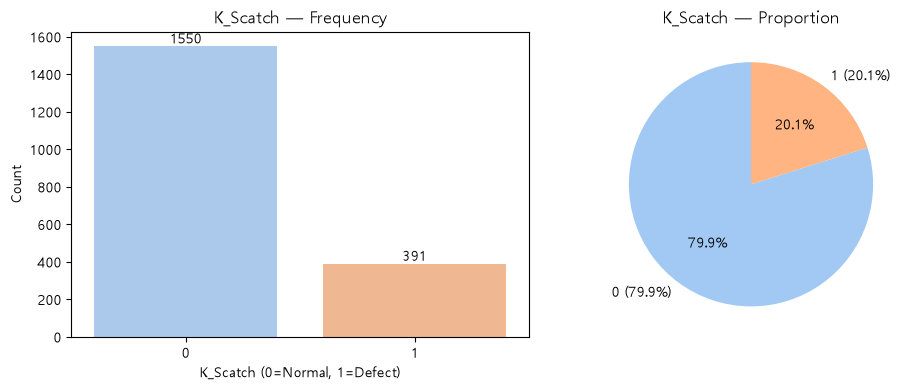


Imbalance ratio (0 : 1) ≈ 3.96 : 1
Positive class (K_Scatch=1) share: 20.14%


In [17]:
# B-1) K_Scatch 클래스 불균형 시각화

TARGET = "K_Scatch"

counts = steel_data[TARGET].value_counts().sort_index()
ratios = steel_data[TARGET].value_counts(normalize=True).sort_index()

print("Class counts:")
print(counts)
print("\nClass ratios:")
print(ratios.round(4))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# 1) 빈도 (count)
sns.countplot(data=steel_data, x=TARGET, ax=axes[0], palette="pastel")
axes[0].set_title("K_Scatch — Frequency")
axes[0].set_xlabel("K_Scatch (0=Normal, 1=Defect)")
axes[0].set_ylabel("Count")
for p in axes[0].patches:
    axes[0].annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center", va="bottom",
    )

# 2) 비율 (proportion)
labels = [f"{idx} ({ratios[idx]:.1%})" for idx in counts.index]
axes[1].pie(
    counts,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("pastel"),
)
axes[1].set_title("K_Scatch — Proportion")

plt.tight_layout()
plt.show()

# 요약
imbalance_ratio = counts[0] / counts[1]
print(f"\nImbalance ratio (0 : 1) ≈ {imbalance_ratio:.2f} : 1")
print(f"Positive class (K_Scatch=1) share: {ratios[1]:.2%}")

결과: 0 약 1,550건(80%), 1 약 391건(20%) — 불균형이 있어 이후 stratify=Y 분할·class_weight 등을 검토하면 됩니다.

---
## B-2) 데이터 전처리

### B-2-1) 타겟 변수 정의

**[과제]** 써니는 K_Scatch를 분류 타겟(0/1)으로 사용하여 모델을 만들려고 합니다. 그런데 다른 결함 유형 변수들이 예측에 어떤 영향을 주는지 궁금해졌습니다. AI와 함께 각 결함 변수와 K_Scatch의 관계를 분석하고, 실제 공정 특성을 학습하기보다 정답을 미리 알려주는 역할을 하는 변수가 있는지 탐색해 보세요. 이후 이러한 변수들을 어떻게 처리하는 것이 적절할지 고민하고 적절한 전처리 방법을 적용해보세요.

[프롬프트]
stratify=Y 분할, class_weight 옵션을 쓰는 것이 좋겠습니다. 그보다 먼저, 각 결함 변수와 K_Scatch의 관계를 분석해서 데이터 누수가 예상되지는 않는지 검토가 필요합니다. 탐색하는 코드를 작성해주고, 그다음 이러한 변수를 어떻게 처리하는 것이 적절할지 추천해줘.

### B-2-2) 결측치 확인 및 데이터 분할

**[과제]** 써니는 데이터셋에 존재하는 클래스 불균형이 모델 학습과 평가에 영향을 줄 수 있다고 생각했습니다. AI와 함께 타겟 변수의 분포를 확인하고 원본 데이터의 클래스 비율이 학습 데이터와 테스트 데이터에도 유지될 수 있도록 적절한 데이터 분할 방법을 적용해 보세요.

### B-2-3) 스케일링/인코딩 필요 여부 검토

**[과제]** 써니는 Day 2에서 로지스틱 회귀 모델 학습을 위해 스케일링을 적용했었습니다. 이번에 사용할 앙상블 모델들도 동일한 전처리가 필요한지 궁금해졌습니다. AI와 함께 모델별 특성을 살펴보고 스케일링과 인코딩이 필요한지 판단하여 적절한 전처리를 적용해 보세요.

---
## B-3) 모델 학습 및 예측

**[과제]** 써니는 Day 2에서 학습한 회귀 모델과 Day 3에서 학습한 앙상블 모델을 동일한 데이터셋에 적용하여 성능을 비교해 보고자 합니다. AI와 함께 모델 학습, 예측, 성능 평가 코드를 작성하고, 여러 모델의 결과를 한눈에 비교할 수 있는 방법을 찾아 성능을 비교 및 분석해 보세요.

---
## B-5) 모델 결과 분석 및 고도화

**[과제]** 써니는 클래스 불균형이 성능에 영향을 줄 수 있다고 생각했습니다. 다만 모델마다 불균형을 다루는 방식이 다르다는 것을 알게 되었습니다. AI와 함께 각 모델에 맞는 불균형 완화 방법을 적용하고 적용 전후 성능을 비교해 보세요.

> 예:Random Forest는 `class_weight`, GBM은 `sample_weight`, XGBoost는 `scale_pos_weight`, LightGBM은 `is_unbalance`, CatBoost는 `auto_class_weights`

**[과제]** 써니는 불균형 완화까지 적용한 5개 모델의 변수 중요도를 비교해서, K_Scatch 결함 여부에 공통적으로 큰 영향을 주는 변수가 무엇인지 확인하려고 합니다. AI와 상의해서 비교 시각화를 만들어 보세요.

**[과제]** 써니는 불균형 완화 이후 F1-score가 가장 좋았던 모델의 성능을 하이퍼파라미터 튜닝으로 더 끌어올리고 싶습니다. AI와 함께 적절한 탐색 범위를 설정하여 GridSearchCV로 성능을 개선해 보세요.